### 선형회귀 직접구현

- Multi-variable (Python 자료형)

In [6]:
from sklearn.datasets import make_regression

n_data = 5000
n_features = 100

X, y = make_regression(n_samples=n_data, n_features=n_features, noise=50, bias=200)

In [7]:
X = X.tolist()
y = y.tolist()

In [ ]:
# 행 = 데이터 개수
# 열 = feature 수
X # shape = (5000, 100)
y # shape = (5000, )

In [ ]:
# hypothesis = WX + b
# cost = MSE

In [ ]:
# 가중치 랜덤 초기화
import random

weights = [random.random() for _ in range(n_features)]
bias = random.random()
weights # 100,

In [ ]:
count = 0
for j in range(n_features):
    w = weights[j]
    x = X[0][j]

for w, x in zip(weights, X[0]):
    # print(w, x)
    w*x
    count += 1
print(count)

In [ ]:
# y_pred 계산 - 데이터 수만큼 나와야 함
y_preds = []
for i in range(n_data):
    # y_pred = w1x1 + w2x2 + w3x3 + ... + w100x100 + bias
    y_pred = bias

    # 반복문
    for w, x in zip(weights, X[i]):
        y_pred += w*x

    y_preds.append(y_pred)

In [26]:
# Cost 계산 mean( (y_pred - y_real) ** 2 ) -> MSE

# 데이터 수만큼 err 계산해준다. 
# 제곱한다.
# 다 더한다.
# 평균낸다.

# for i in range(n_data):
#     prediction = y_preds[i]
#     real = y[i]

cost = 0
for p, r in zip(y_preds, y):
    err = p - r
    cost += err**2

cost /= n_data
cost

75805.96581693913

In [32]:
# 가중치 업데이트
# 1. 기울기 0으로 초기화
dweights = [0] * n_features
dbias = 0

# 2. 데이터 하나씩 돌면서,
for p, r, x in zip(y_preds, y, X): # n_data
    p # 1
    r # 1
    x # 100
    # for i in range(len(x)):
    # 3. feature마다, 
    for i in range(n_features):
        # 4. dw[i] 기울기에 누적해준다. 2 * err * x[i]
        dweights[i] += 2 * (p - r) * x[i]

    dbias += 2 * (p - r) * 1

# 5. 평균내주기
dweights = [dw/n_data for dw in dweights]
dbias /= n_data

In [34]:
epochs = 1000
learning_rate = 0.01

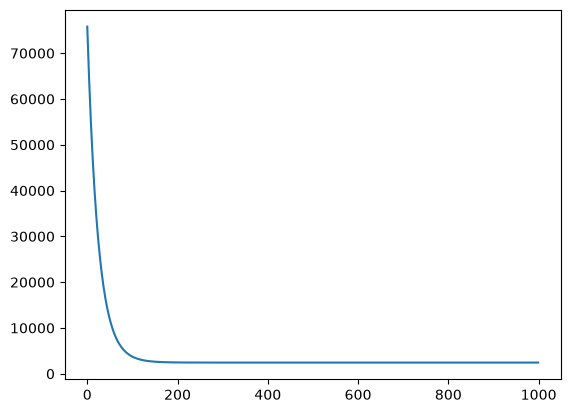

In [ ]:
from tqdm import tqdm

history = {
    'cost': []
}

for epoch in tqdm(range(epochs)):
    # 1. y_preds 계산
    y_preds = []
    for i in range(n_data):
        y_pred = bias
        for w, x in zip(weights, X[i]):
            y_pred += w*x
        y_preds.append(y_pred)

    # 2. cost 계산
    cost = 0
    for p, r in zip(y_preds, y):
        err = p - r
        cost += err**2
    cost /= n_data

    history['cost'].append(cost)

    # 3. weights 업데이트
    for p, r, x in zip(y_preds, y, X): # n_data
        for i in range(n_features):
            dweights[i] += 2 * (p - r) * x[i]
        dbias += 2 * (p - r) * 1

    dweights = [dw/n_data for dw in dweights]
    dbias /= n_data

    # 업데이트
    weights = [w - learning_rate*dw for w, dw in zip(weights, dweights)]
    bias -= learning_rate * dbias

import matplotlib.pyplot as plt
plt.plot(history['cost'])
plt.show()

# 파이썬 순수 자료형 구현, 1000회 소요시간 114.6s

- Numpy 활용

In [36]:
import numpy as np

In [37]:
from sklearn.datasets import make_regression

n_data = 5000
n_features = 100

X, y = make_regression(n_samples=n_data, n_features=n_features, noise=50, bias=200)

In [38]:
weights = np.random.random(n_features)
bias = np.random.random(1)

In [41]:
# 1. y_pred
y_pred = X @ weights + bias
y_pred[:10]

array([  6.77918991,  -6.52819668,  -7.30746781,  -4.82231716,
        -0.75643095, -11.81656218,   4.28563445,  -6.25488632,
        -5.44234987,  -2.08274656])

In [ ]:
# 2. cost
cost = np.mean( (y_pred - y) ** 2 )
cost

np.float64(64554.327840043916)

In [ ]:
((y_pred - y) * X) # ValueError

(100,)

In [ ]:
# 가중치 업데이트
dweights = 2 * (y_pred - y) @ X / n_data # -> 100,
dbias = np.mean(2 * y_pred - y)

In [ ]:
epochs = 1000
learning_rate = 0.01

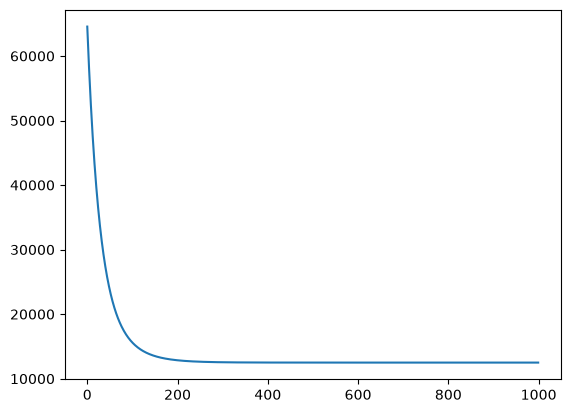

In [ ]:
history = {
    'cost': []
}

for epoch in range(epochs):
    y_pred = X @ weights + bias
    cost = np.mean( (y_pred - y) ** 2 )
    history['cost'].append(cost)

    dweights = 2 * (y_pred - y) @ X / n_data # -> 100,
    dbias = np.mean(2 * y_pred - y)

    weights -= learning_rate * dweights
    bias -= learning_rate * dbias

import matplotlib.pyplot as plt
plt.plot(history['cost'])
plt.show()

# numpy 계산 소요시간 0.3s

In [ ]:
# 가중치에 w0 포함
weights = np.random.random(n_features + 1)
# X.shape
# X에 bias용 1 추가해주는거
X = np.hstack([X, np.ones([n_data, 1])])

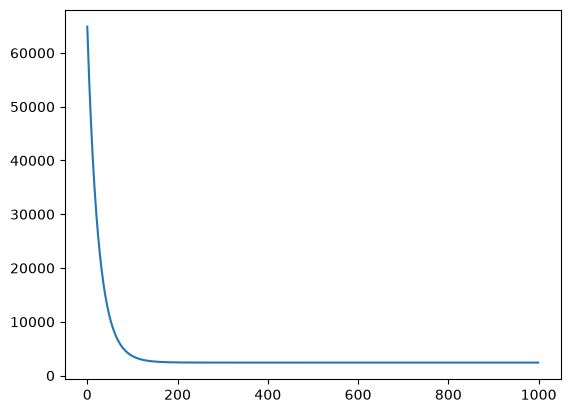

In [ ]:
history = {
    'cost': []
}

for epoch in range(epochs):
    y_pred = X @ weights
    cost = np.mean( (y_pred - y) ** 2 )
    history['cost'].append(cost)

    dweights = 2 * (y_pred - y) @ X / n_data # -> 101,
    weights -= learning_rate * dweights

import matplotlib.pyplot as plt
plt.plot(history['cost'])
plt.show()

# numpy 계산 소요시간 0.3s